In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats  # For hypothesis testing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_squared_error, accuracy_score, confusion_matrix, classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import mean_squared_error, r2_score

In [35]:
df = pd.read_csv('/content/mental_health_physical_activity.csv')
df

,ID,Age,Gender,Occupation,Sleep_Hours,Daily_Steps,Exercise_Frequency,Exercise_Duration,Exercise_Type,Screen_Time_Hours,Diet_Quality,Social_Interaction,Stress_Level,Anxiety_Level,Depression_Level,Happiness_Level,Mental_Health_Score,Notes
0,1,58,Male,Student,7.7,5012,3,12.6,Cardio,7.1,5,2,10,7,1,1,-4.0,NaN
1,2,23,Male,Working Professional,6.5,1434,3,64.4,NaN,5.9,2,14,10,5,1,3,0.7,NaN
2,3,62,Female,Unemployed,5.4,4527,5,9.2,Sports,1.9,3,19,5,1,8,9,13.3,NaN
3,4,25,Female,Student,6.8,14588,5,52.0,NaN,1.6,2,9,2,4,2,7,11.3,NaN
4,5,35,Female,Unemployed,4.8,6820,3,60.3,NaN,9.4,1,19,3,9,4,3,0.7,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
295,296,62,Female,Working Professional,7.8,1529,5,73.3,Cardio,6.5,5,7,9,7,4,9,11.3,NaN
296,297,62,Female,Student,8.6,7349,6,86.1,NaN,3.8,5,1,1,5,4,10,16.7,NaN
297,298,46,Male,Unemployed,7.8,9955,3,69.9,Strength,3.6,2,2,3,3,9,2,-1.0,NaN
298,299,42,Male,Retired,5.4,5329,2,14.5,Yoga,1.1,4,4,1,3,6,10,16.7,NaN


In [36]:
# Preview
df.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   300 non-null    int64  
 1   Age                  300 non-null    int64  
 2   Gender               300 non-null    object 
 3   Occupation           300 non-null    object 
 4   Sleep_Hours          300 non-null    float64
 5   Daily_Steps          300 non-null    int64  
 6   Exercise_Frequency   300 non-null    int64  
 7   Exercise_Duration    300 non-null    float64
 8   Exercise_Type        252 non-null    object 
 9   Screen_Time_Hours    300 non-null    float64
 10  Diet_Quality         300 non-null    int64  
 11  Social_Interaction   300 non-null    int64  
 12  Stress_Level         300 non-null    int64  
 13  Anxiety_Level        300 non-null    int64  
 14  Depression_Level     300 non-null    int64  
 15  Happiness_Level      300 non-null    int

In [37]:

# 1. Drop the "Notes" column because it contains 0 non-null values.
df.drop(columns=["Notes"], inplace=True)

# 2. Fill missing values in 'Exercise_Type' (categorical) with "Unknown"
df["Exercise_Type"] = df["Exercise_Type"].fillna("Unknown")

# Verify missing values again
print("\nMissing values after cleaning:")
print(df.isnull().sum())

# -----------------------------------------------------------
# BASIC DATA CLEANING
# -----------------------------------------------------------

# Check duplicates
print("\nNumber of duplicates:", df.duplicated().sum())

# Remove duplicates (if any)
df = df.drop_duplicates()


Missing values after cleaning:
ID                     0
Age                    0
Gender                 0
Occupation             0
Sleep_Hours            0
Daily_Steps            0
Exercise_Frequency     0
Exercise_Duration      0
Exercise_Type          0
Screen_Time_Hours      0
Diet_Quality           0
Social_Interaction     0
Stress_Level           0
Anxiety_Level          0
Depression_Level       0
Happiness_Level        0
Mental_Health_Score    0
dtype: int64

Number of duplicates: 0


In [38]:
# -----------------------------------------------------------
# DESCRIPTIVE STATISTICS
# -----------------------------------------------------------

# Summary statistics for numeric columns
print("\nDescriptive statistics:")
print(df.describe())

# Frequency counts for categorical columns
print("\nGender distribution:")
print(df['Gender'].value_counts())

print("\nOccupation distribution:")
print(df['Occupation'].value_counts())



Descriptive statistics:
               ID         Age  Sleep_Hours   Daily_Steps  Exercise_Frequency  \
count  300.000000  300.000000   300.000000    300.000000          300.000000   
mean   150.500000   42.593333     6.473667   8208.640000            3.616667   
std     86.746758   14.325222     1.439879   3998.281772            2.202854   
min      1.000000   18.000000     4.000000   1025.000000            0.000000   
25%     75.750000   30.000000     5.200000   4849.250000            2.000000   
50%    150.500000   42.000000     6.550000   8462.000000            4.000000   
75%    225.250000   56.250000     7.700000  11842.750000            5.250000   
max    300.000000   65.000000     9.000000  14947.000000            7.000000   

       Exercise_Duration  Screen_Time_Hours  Diet_Quality  Social_Interaction  \
count         300.000000         300.000000    300.000000          300.000000   
mean           40.410667           5.380000      3.003333           10.166667   
std        

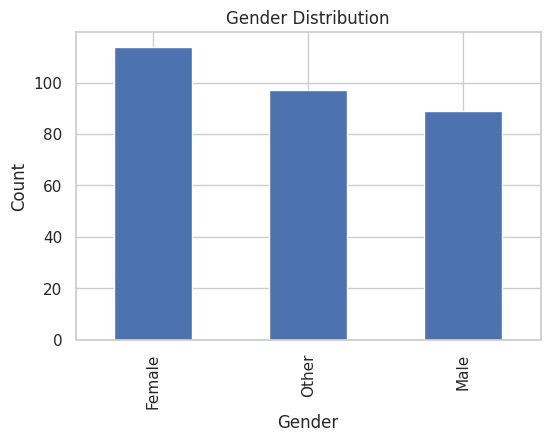

In [39]:
# -----------------------------------------------------------
# VISUALISATIONS (7–8 Graphs)
# -----------------------------------------------------------

# Make plots look nicer
sns.set(style="whitegrid")

# 1. Bar chart – Gender distribution
plt.figure(figsize=(6,4))
df['Gender'].value_counts().plot(kind='bar')
plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()

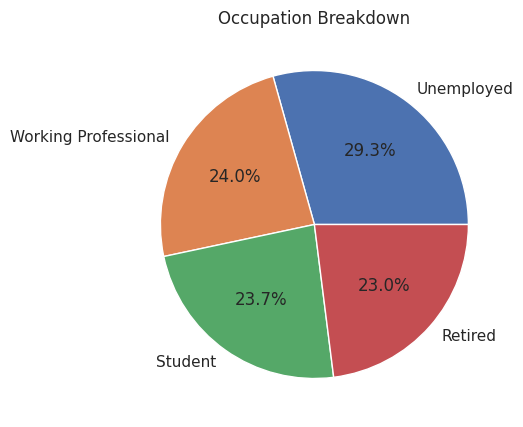

In [40]:
# 2. Pie chart – Occupation distribution
plt.figure(figsize=(5,5))
df['Occupation'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("Occupation Breakdown")
plt.ylabel("")
plt.show()

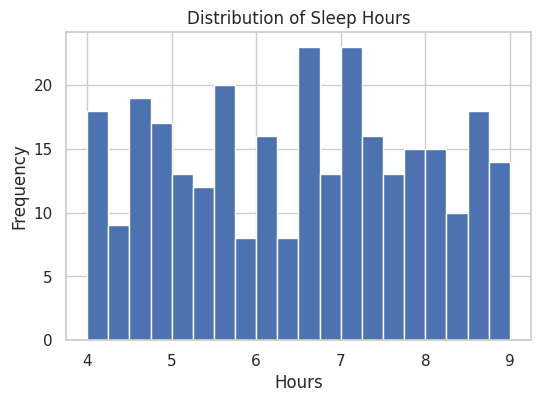

In [41]:
# 3. Histogram – Sleep Hours
plt.figure(figsize=(6,4))
df['Sleep_Hours'].plot(kind='hist', bins=20)
plt.title("Distribution of Sleep Hours")
plt.xlabel("Hours")
plt.ylabel("Frequency")
plt.show()

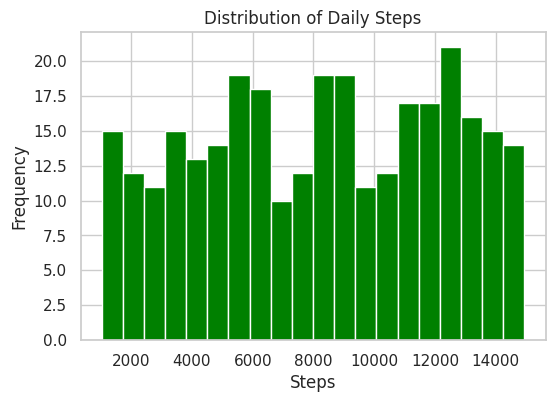

In [42]:
# 4. Histogram – Daily Steps
plt.figure(figsize=(6,4))
df['Daily_Steps'].plot(kind='hist', bins=20, color='green')
plt.title("Distribution of Daily Steps")
plt.xlabel("Steps")
plt.ylabel("Frequency")
plt.show()


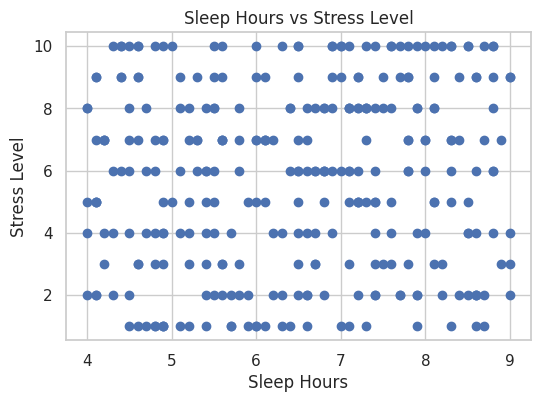

In [43]:
# 5. Scatter Plot – Sleep Hours vs Stress Level
plt.figure(figsize=(6,4))
plt.scatter(df['Sleep_Hours'], df['Stress_Level'])
plt.title("Sleep Hours vs Stress Level")
plt.xlabel("Sleep Hours")
plt.ylabel("Stress Level")
plt.show()


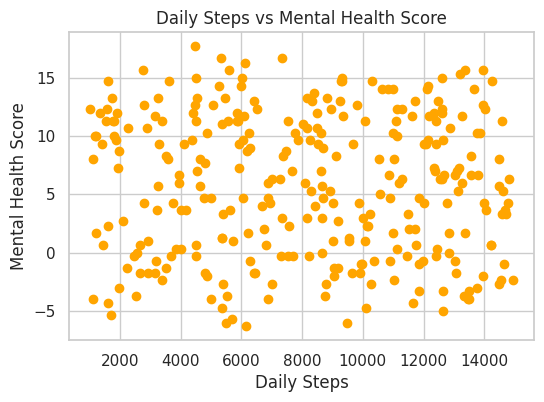

In [44]:
# 6. Scatter Plot – Daily Steps vs Mental Health Score
plt.figure(figsize=(6,4))
plt.scatter(df['Daily_Steps'], df['Mental_Health_Score'], color='orange')
plt.title("Daily Steps vs Mental Health Score")
plt.xlabel("Daily Steps")
plt.ylabel("Mental Health Score")
plt.show()

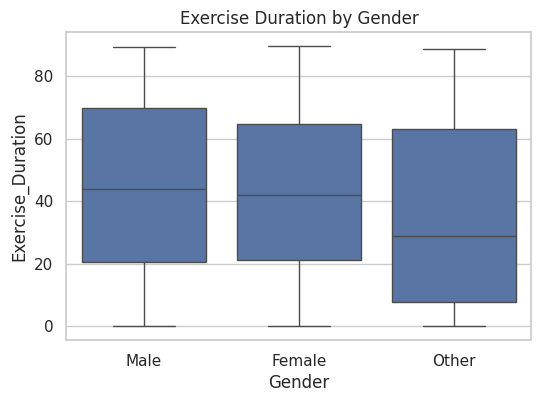

In [45]:
# 7. Box Plot – Exercise Duration by Gender
plt.figure(figsize=(6,4))
sns.boxplot(x='Gender', y='Exercise_Duration', data=df)
plt.title("Exercise Duration by Gender")
plt.show()

In [46]:
# 1. HYPOTHESIS TESTING
# -----------------------------------------------------------

# 1a. Independent t-test: Compare Sleep Hours between Male and Female
male_sleep = df[df['Gender'] == 'Male']['Sleep_Hours']
female_sleep = df[df['Gender'] == 'Female']['Sleep_Hours']

t_stat, p_value = stats.ttest_ind(male_sleep, female_sleep, nan_policy='omit')
print(f"T-test result for Sleep Hours (Male vs Female): t={t_stat:.3f}, p={p_value:.3f}")

# 1b. Chi-square test: Association between Gender and Exercise_Type
contingency_table = pd.crosstab(df['Gender'], df['Exercise_Type'])
chi2, p, dof, expected = stats.chi2_contingency(contingency_table)
print(f"Chi-square test: chi2={chi2:.3f}, p={p:.3f}, dof={dof}")

# 1c. ANOVA: Compare Mental Health Score across Occupations
groups = [df[df['Occupation'] == occ]['Mental_Health_Score'] for occ in df['Occupation'].unique()]
f_stat, p_val = stats.f_oneway(*groups)
print(f"ANOVA for Mental Health Score by Occupation: F={f_stat:.3f}, p={p_val:.3f}")

T-test result for Sleep Hours (Male vs Female): t=-0.861, p=0.390
Chi-square test: chi2=17.481, p=0.064, dof=10
ANOVA for Mental Health Score by Occupation: F=0.365, p=0.778


In [47]:


# -----------------------------------------------------------
# LINEAR REGRESSION EVALUATION
# -----------------------------------------------------------

# 1. Mean Squared Error (MSE)
mse = mean_squared_error(y_test, y_pred)
print(f"MSE: {mse:.3f}")

# 2. Root Mean Squared Error (RMSE)
rmse = np.sqrt(mse)
print(f"RMSE: {rmse:.3f}")

# 3. Mean Absolute Percentage Error (MAPE)
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100
print(f"MAPE: {mape:.2f}%")

# 4. R-squared (Coefficient of Determination)
r2 = r2_score(y_test, y_pred)
print(f"R² Score: {r2:.3f}")

MSE: 25.032
RMSE: 5.003
MAPE: inf%
R² Score: -100.939


In [48]:
# 2b. Logistic Regression: Predict if Happiness_Level > 5 (binary classification)
df['Happy'] = (df['Happiness_Level'] > 5).astype(int)
X_log = df[['Sleep_Hours', 'Daily_Steps', 'Exercise_Duration']]
y_log = df['Happy']

X_train, X_test, y_train, y_test = train_test_split(X_log, y_log, test_size=0.2, random_state=42)
log_model = LogisticRegression()
log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_log))
print(classification_report(y_test, y_pred_log))

Logistic Regression Accuracy: 0.6666666666666666
              precision    recall  f1-score   support

           0       0.65      0.50      0.57        26
           1       0.68      0.79      0.73        34

    accuracy                           0.67        60
   macro avg       0.66      0.65      0.65        60
weighted avg       0.66      0.67      0.66        60



Random Forest Accuracy: 0.65
[[16 10]
 [11 23]]


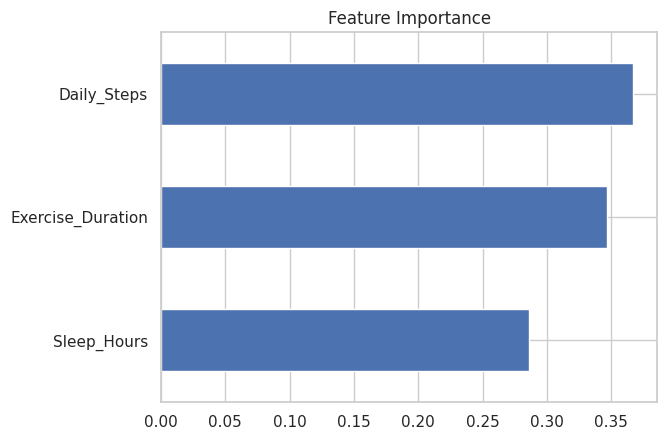

In [49]:
# 3. PREDICTIVE MODELING
# -----------------------------------------------------------

# Random Forest Classifier to predict 'Happy'
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(confusion_matrix(y_test, y_pred_rf))

# Feature importance
feat_importances = pd.Series(rf_model.feature_importances_, index=X_train.columns)
feat_importances.sort_values().plot(kind='barh', title="Feature Importance")
plt.show()


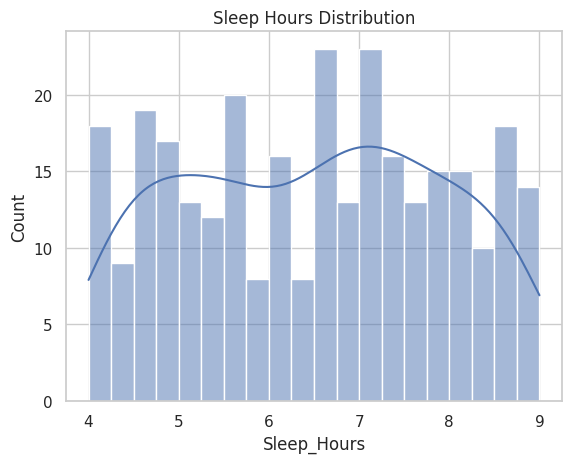

Shapiro-Wilk Test for Sleep Hours: W=0.957, p=0.000
Probability of exactly 50 happy people: 0.00000


In [50]:
# 4. PROBABILITY DISTRIBUTIONS
# -----------------------------------------------------------

# Histogram + Normal distribution fit for Sleep_Hours
sns.histplot(df['Sleep_Hours'], kde=True, bins=20)
plt.title("Sleep Hours Distribution")
plt.show()

# Shapiro-Wilk Test for Normality
shapiro_stat, shapiro_p = stats.shapiro(df['Sleep_Hours'].dropna())
print(f"Shapiro-Wilk Test for Sleep Hours: W={shapiro_stat:.3f}, p={shapiro_p:.3f}")

# Binomial Distribution example: Probability of being happy
n = len(df)
p_happy = df['Happy'].mean()
binom_prob = stats.binom.pmf(k=50, n=n, p=p_happy)  # Probability exactly 50 happy
print(f"Probability of exactly 50 happy people: {binom_prob:.5f}")